In [ ]:
##HW6_Question2

In [ ]:
##1.2.Dataset location
Data_dir="/home/ya30/Desktop/HW6/archive/kvasir-dataset/"
Data_dir2="/home/ya30/Desktop/HW6/Dataset2/processed/"
Normal_classes=["normal-cecum","normal-z-line","normal-pylorus"]
polyp_class="polyps"

In [2]:
##making new dataset
import torchvision.transforms as transforms
from torchvision.transforms import functional as TF

class Min_SquareCenterCrop:
    def __call__(self, img):
        min_side = min(img.width, img.height)
        return TF.center_crop(img, (min_side, min_side))

transform = transforms.Compose([
    Min_SquareCenterCrop(),            
    transforms.Resize((96, 96)),   
    transforms.ToTensor(),         
])

In [ ]:
import os
from PIL import Image
from torch.utils.data import Dataset
from tqdm import tqdm

class DATASET_maker(Dataset):

    def __init__(self, image_paths, transform):
        self.image_paths=image_paths
        self.transform=transform

    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path= self.image_paths[idx]
        img= Image.open(img_path).convert('RGB')
        img_transformed= self.transform(img)
        fname=os.path.basename(img_path)
        return img_transformed, fname
    
    def savingImages(self, save_dir):
       
        for i in tqdm(range(len(self))):
            img_tensor, fname=self[i]
            img_np=(img_tensor.permute(1, 2, 0).numpy() * 255).astype('uint8')
            Image.fromarray(img_np).save(os.path.join(save_dir, fname))


In [4]:
##noraml dataset
from glob import glob
normal_original_paths=[os.path.join(Data_dir, cls) for cls in Normal_classes]
normal_final_path=os.path.join(Data_dir2,"normal/")
normal_images = []

for path in normal_original_paths:
    normal_images.extend(glob(os.path.join(path, '*.jpg')))

normal_dataset=DATASET_maker(normal_images, transform)   
normal_dataset.savingImages(normal_final_path)

100%|██████████| 1500/1500 [00:45<00:00, 33.03it/s]


In [15]:
##polyps datset
polyp_original_path=os.path.join(Data_dir,polyp_class)
print(polyp_original_path)
polyp_final_path=os.path.join(Data_dir2,"polyp/")
polyp_images=glob(os.path.join(polyp_original_path, '*.jpg'))

polyp_dataset=DATASET_maker(polyp_images, transform) 
polyp_dataset.savingImages(polyp_final_path)

/home/ya30/Desktop/HW6/archive/kvasir-dataset/polyps


100%|██████████| 500/500 [00:08<00:00, 58.20it/s]


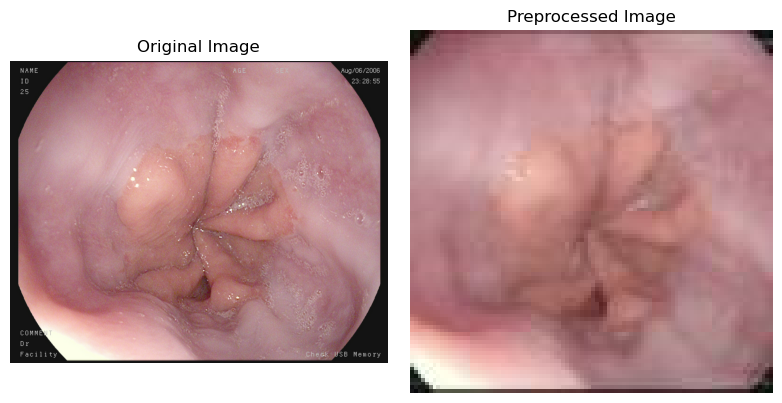

In [ ]:
import matplotlib.pyplot as plt
import random

#Choosing a random processed image
processed_sample=random.choice(os.listdir(normal_final_path))
processed_path=os.path.join(normal_final_path, processed_sample)

#Finding original image
original_path=None
for orig_dir in normal_original_paths:
    candidate=os.path.join(orig_dir, processed_sample)
    if os.path.exists(candidate):
        original_path = candidate
        break

#printing
original=Image.open(original_path).convert('RGB')
processed=Image.open(processed_path)

fig, axs=plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(original)
axs[0].set_title("Original Image")
axs[0].axis("off")

axs[1].imshow(processed)
axs[1].set_title("Preprocessed Image")
axs[1].axis("off")

plt.tight_layout()
plt.savefig("sample1.png")
plt.show()



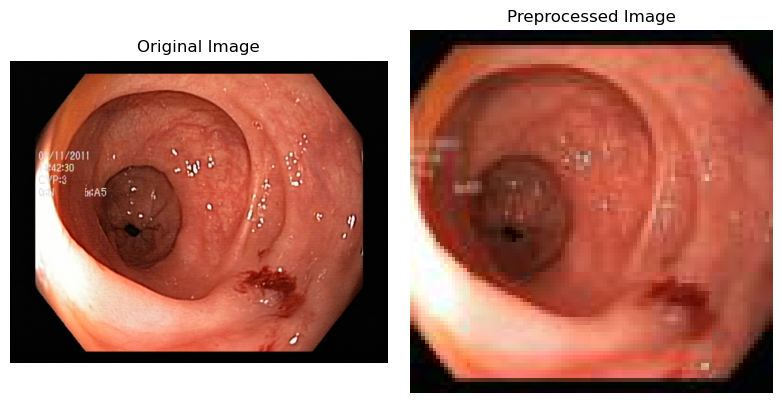

In [36]:
##showing samples
import matplotlib.pyplot as plt
import random

#choosing a random processed image
processed_sample=random.choice(os.listdir(polyp_final_path))
processed_path=os.path.join(polyp_final_path, processed_sample)
original_path=os.path.join(polyp_original_path, processed_sample)

original=Image.open(original_path).convert('RGB')
processed=Image.open(processed_path)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(original)
axs[0].set_title("Original Image")
axs[0].axis("off")

axs[1].imshow(processed)
axs[1].set_title("Preprocessed Image")
axs[1].axis("off")

plt.tight_layout()
plt.savefig("samplePolyp.png")
plt.show()


In [ ]:
#2.2.making the model
import torch
import torch.nn as nn
import torch.nn.functional as F

class EndoVAE(nn.Module):
    def __init__(self, latent_dim=6):
        super(EndoVAE, self).__init__()
        self.latent_dim=latent_dim

        #Encoderr
        self.encoder=nn.Sequential(
            #1
            nn.Conv2d(3, 16, 3,stride=1, padding=1), 
            nn.ReLU(),
            #2
            nn.Conv2d(16, 32, 3,stride=1, padding=1),  
            nn.ReLU(),
            #3
            nn.Conv2d(32, 32, 3,stride=2, padding=1), 
            nn.ReLU(),
            #4
            nn.Conv2d(32, 64, 3,stride=2, padding=1),
            nn.ReLU(),
            #5
            nn.Conv2d(64, 128, 3,stride=2, padding=1),          
            nn.ReLU(),
            #6
            nn.Conv2d(128, 256, 3,stride=2, padding=1),
                   
            nn.ReLU(),
        )
        
        self.flatten=nn.Flatten()
        ##2 Fc routes
        self.fc_mu=nn.Linear(256 * 6 * 6, latent_dim)
        self.fc_logvar=nn.Linear(256 * 6 * 6, latent_dim)
        
        # Decoder
        self.fc_decode=nn.Linear(latent_dim, 256 * 6 * 6)
        self.decoder=nn.Sequential(
            #1
            nn.ConvTranspose2d(256, 256, 3,stride=2, padding=1, output_padding=1),    
            nn.ReLU(),
            #2
            nn.ConvTranspose2d(256,128, 3,stride=1, padding=1),   
            nn.ReLU(),
            #3
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),  
            nn.ReLU(),
            #4
            nn.ConvTranspose2d(64, 64, 3, stride=1, padding=1),   
            nn.ReLU(),
            #5
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),    
            nn.ReLU(),
            #6
            nn.ConvTranspose2d(32, 32, 3, stride=1, padding=1),   
            nn.ReLU(),
            #7
            nn.ConvTranspose2d(32, 3, 3, stride=2,padding=1, output_padding=1),                   
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std=torch.exp(0.5 * logvar)
        eps=torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x=self.encoder(x)
        #print("encoder output shape:", x.shape)
        x=self.flatten(x)
        mu=self.fc_mu(x)
        logvar=self.fc_logvar(x)
        z=self.reparameterize(mu, logvar)

        x_decoded=self.fc_decode(z)
        x_decoded=x_decoded.view(-1, 256, 6, 6)
        x_h_out=self.decoder(x_decoded)
        return x_h_out, mu, logvar


In [ ]:
##2.3 loss function
def Loss_Function_VAE (x,x_h,mu,logvar):
    ##reconstruction loss , binary cE over all pixels sum over all pixels
    r_loss=F.binary_cross_entropy(x_h, x, reduction='sum') /x.size(0)
    ##KL Divergance
    kl_div=-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())/x.size(0)
    loss_total=r_loss+ 1.0*kl_div

    return loss_total, kl_div , r_loss

In [ ]:
##2.4 Trainnig
from torch.utils.data import DataLoader
#from torchvision import transforms, models, datasets

#normal_final_path=os.path.join(Data_dir2,"normal/")
#transform=transforms.ToTensor()
#df_X_normal=datasets.ImageFolder(root=normal_final_path, transform=transform)
#train_loader_normal=DataLoader(df_X_normal ,batch_size=128, shuffle=True)
train_loader_normal=DataLoader(normal_dataset ,batch_size=128, shuffle=True)


In [9]:
from torchsummary import summary
torch.manual_seed(42)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=EndoVAE().to(device)
summary(model, input_size=(3,96,96))

Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Conv2d: 2-1                       448
|    └─ReLU: 2-2                         --
|    └─Conv2d: 2-3                       4,640
|    └─ReLU: 2-4                         --
|    └─Conv2d: 2-5                       9,248
|    └─ReLU: 2-6                         --
|    └─Conv2d: 2-7                       18,496
|    └─ReLU: 2-8                         --
|    └─Conv2d: 2-9                       73,856
|    └─ReLU: 2-10                        --
|    └─Conv2d: 2-11                      295,168
|    └─ReLU: 2-12                        --
├─Flatten: 1-2                           --
├─Linear: 1-3                            55,302
├─Linear: 1-4                            55,302
├─Linear: 1-5                            64,512
├─Sequential: 1-6                        --
|    └─ConvTranspose2d: 2-13             590,080
|    └─ReLU: 2-14                        --
|    └─ConvTranspose2d: 2-15      

Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Conv2d: 2-1                       448
|    └─ReLU: 2-2                         --
|    └─Conv2d: 2-3                       4,640
|    └─ReLU: 2-4                         --
|    └─Conv2d: 2-5                       9,248
|    └─ReLU: 2-6                         --
|    └─Conv2d: 2-7                       18,496
|    └─ReLU: 2-8                         --
|    └─Conv2d: 2-9                       73,856
|    └─ReLU: 2-10                        --
|    └─Conv2d: 2-11                      295,168
|    └─ReLU: 2-12                        --
├─Flatten: 1-2                           --
├─Linear: 1-3                            55,302
├─Linear: 1-4                            55,302
├─Linear: 1-5                            64,512
├─Sequential: 1-6                        --
|    └─ConvTranspose2d: 2-13             590,080
|    └─ReLU: 2-14                        --
|    └─ConvTranspose2d: 2-15      

In [10]:
##optimizer
optimizer=torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
import time
ENumbers=150
save_path="/home/ya30/Desktop/HW6/model/LastModel2.pth"
number_pixel=96*96*3
for epoch in range(ENumbers):
    start_time=time.time()
    model.train()
    running_total_loss=0.0
    running_rc_loss=0.0
    running_kl_div=0.0

    for tr_images,_ in train_loader_normal:
        tr_images=tr_images.to(device)

        x_hat,mu,logvar=model(tr_images)
        T_loss, kl, rc =Loss_Function_VAE(tr_images, x_hat, mu, logvar)
        optimizer.zero_grad()
        T_loss.backward()
        optimizer.step()
        running_total_loss+=T_loss.item()
        running_rc_loss+=rc.item()
        running_kl_div+=kl.item()

    avg_total=running_total_loss/ len(train_loader_normal.dataset)
    avg_rc=running_rc_loss/ len(train_loader_normal.dataset)
    avg_kl=running_kl_div/ len(train_loader_normal.dataset)

    if (epoch+1)%10==0 or epoch==0:
     current_time=time.time()
     total_time=current_time-start_time
     print(f'Epoch =[{epoch+1} in {ENumbers}] Training takes {total_time/60} minutes')
     print(f'loss per image:')
     print(f'Total Training Loss: {avg_total:.4f} **KL_Divergence: {avg_kl:.4f} ** Reconstruction loss: {avg_rc:.4f}')
     print(f'loss per pixel %:')
     print(f'Total Training Loss: {100*(avg_total/number_pixel):.4f} **KL_Divergence: {100*(avg_kl/number_pixel):.4f} ** Reconstruction loss: {100*(avg_rc/number_pixel):.4f}')
     torch.save(model.state_dict(), save_path)
     print('------------------------------------------------------------')

Epoch =[1 in 150] Training takes 0.6090336243311564 minutes
loss per image:
Total Training Loss: 128.2491 **KL_Divergence: 0.1610 ** Reconstruction loss: 128.0881
loss per pixel %:
Total Training Loss: 0.4639 **KL_Divergence: 0.0006 ** Reconstruction loss: 0.4633
------------------------------------------------------------
Epoch =[10 in 150] Training takes 0.5802789012591044 minutes
loss per image:
Total Training Loss: 128.0178 **KL_Divergence: 0.1603 ** Reconstruction loss: 127.8575
loss per pixel %:
Total Training Loss: 0.4630 **KL_Divergence: 0.0006 ** Reconstruction loss: 0.4624
------------------------------------------------------------
Epoch =[20 in 150] Training takes 0.5828187147776286 minutes
loss per image:
Total Training Loss: 127.7742 **KL_Divergence: 0.1587 ** Reconstruction loss: 127.6155
loss per pixel %:
Total Training Loss: 0.4621 **KL_Divergence: 0.0006 ** Reconstruction loss: 0.4616
------------------------------------------------------------
Epoch =[30 in 150] Trai

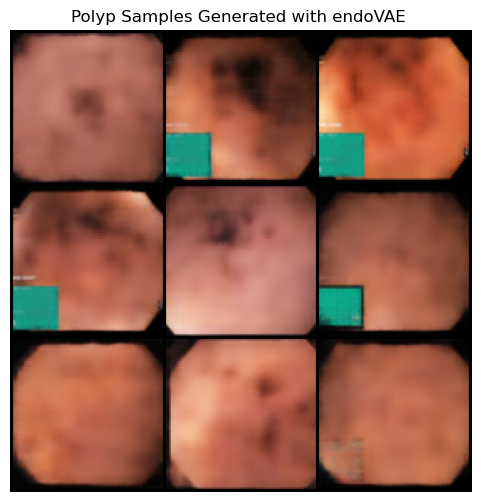

In [ ]:
##2.5 validation..... image generation
import matplotlib.pyplot as plt
import torchvision.utils as vutils

#save_path="/home/ya30/Desktop/HW6/model/LastModel2.pth"
#model.load_state_dict(torch.load(save_path, map_location=device))
#model = model.to(device)

model.eval()
with torch.no_grad():
    z=torch.randn(9, 6).to(device)
    x_gen=model.fc_decode(z).view(-1, 256, 6, 6)
    x_gen=model.decoder(x_gen) 

    grid=vutils.make_grid(x_gen.cpu(), nrow=3, normalize=True)
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title("Polyp Samples Generated with endoVAE ")
    plt.axis("off")
    plt.savefig("generated_samples.png")
    plt.show()


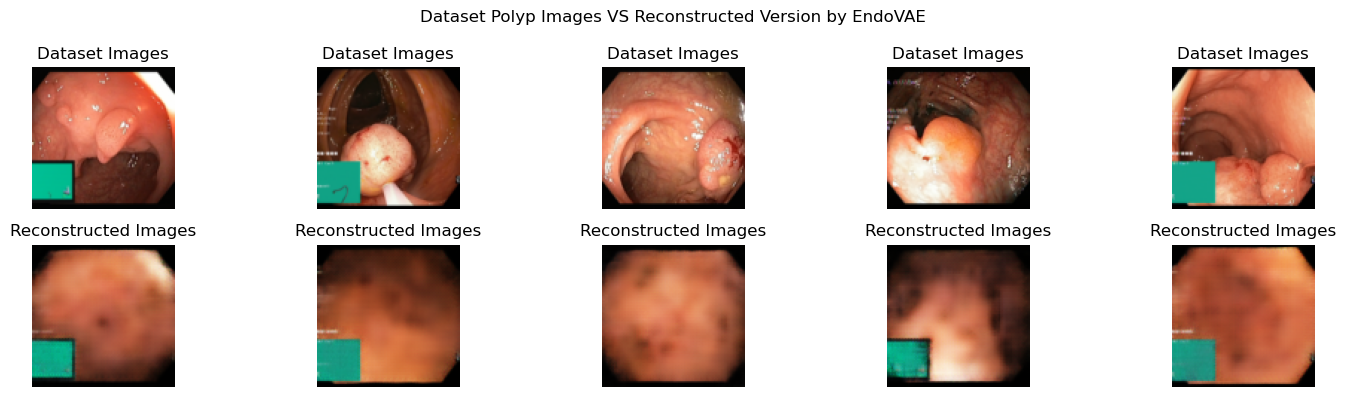

In [ ]:
##reconstruction


polyp_loader=DataLoader(polyp_dataset ,batch_size=5, shuffle=True)
model.eval()
with torch.no_grad():
    # One batch of 5
    images, _ =next(iter(polyp_loader))
    images=images.to(device)

    # Pass through encoder manually
    encoded=model.encoder(images)
    encoded_flat=model.flatten(encoded)
    mu=model.fc_mu(encoded_flat)
    logvar=model.fc_logvar(encoded_flat)

    z=model.reparameterize(mu, logvar)
    x_decoded=model.fc_decode(z)
    x_decoded=x_decoded.view(-1, 256, 6, 6)
    rc_images=model.decoder(x_decoded)

fig, axs=plt.subplots(2, 5, figsize=(15, 4))
for i in range(5):
    axs[0, i].imshow(images[i].cpu().permute(1, 2, 0))
    axs[0, i].set_title("Dataset Images")
    axs[0, i].axis("off")

    axs[1, i].imshow(rc_images[i].cpu().permute(1, 2, 0))
    axs[1, i].set_title("Reconstructed Images")
    axs[1, i].axis("off")

plt.suptitle("Dataset Polyp Images VS Reconstructed Version by EndoVAE")
plt.tight_layout()
plt.savefig("polyp_reconstruction.png")
plt.show()


SSIM:  Mean = 0.4575 | Std = 0.1046
PSNR:  Mean = 17.27 | Std = 2.72


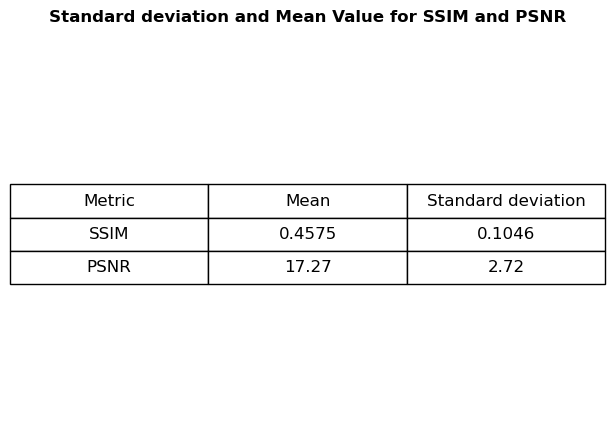

In [ ]:
##2.6 
import numpy as np
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import pandas as pd
polyp_loader2=DataLoader(polyp_dataset ,batch_size=50, shuffle=True)


model.eval()
ssim_scores=[]
psnr_scores=[]
image_names=[]

with torch.no_grad():
    images, names=next(iter(polyp_loader2))
    images=images.to(device)
    recon, _, _ =model(images)

    for i in range(images.size(0)):
        real=images[i].cpu().permute(1,2,0).numpy()
        fake=recon[i].cpu().permute(1,2,0).numpy()
        real=np.clip(real, 0, 1)
        fake=np.clip(fake, 0, 1)

        ssim_val=ssim(real, fake, channel_axis=2, data_range=1.0)
        psnr_val=psnr(real, fake, data_range=1.0)

        ssim_scores.append(ssim_val)
        psnr_scores.append(psnr_val)
        image_names.append(names[i])

# saving for each image in .csv file
df = pd.DataFrame({
    "Image_Name": image_names,
    "SSIM": ssim_scores,
    "PSNR": psnr_scores
})
df.to_csv("per_image_metrics.csv", index=False)

#Mean +std d
mean_ssim=np.mean(ssim_scores)
std_ssim=np.std(ssim_scores)
mean_psnr=np.mean(psnr_scores)
std_psnr=np.std(psnr_scores)

print("SSIM:  Mean =", round(mean_ssim, 4), "| Std =", round(std_ssim, 4))
print("PSNR:  Mean =", round(mean_psnr, 2), "| Std =", round(std_psnr, 2))

# Meand and std table 
table_data=[["Metric", "Mean", "Standard deviation"],["SSIM", f"{mean_ssim:.4f}", f"{std_ssim:.4f}"],["PSNR", f"{mean_psnr:.2f}", f"{std_psnr:.2f}"]]
fig, ax=plt.subplots()
ax.axis('off')
table=ax.table(cellText=table_data, loc='center', cellLoc='center')
table.scale(1.2, 2)
table.set_fontsize(14)
plt.title("Standard deviation and Mean Value for SSIM and PSNR", fontweight='bold', pad=20)
plt.savefig("SSIM_PSNR_mean.png")
plt.show()

